In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import requests  # HTTP library for Python
import bs4
import math
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import gsw
%matplotlib inline
import os
import sys
import xmitgcm 
import xgcm
import pyproj
#import wget
#sys.path.append('../../ECCOv4-py/ECCOv4-py')
#import ecco_v4_py as ecco
import cmocean
sys.path.append('/home/drdarby/Desktop/cape_mend_SM_LCS/datatools')
from datatools import datatools as tools
#from moviepy.config import change_settings
#change_settings({"FFMPEG_BINARY": "/usr/bin/ffmpeg"})
#import moviepy.video.io.ImageSequenceClip 
import airsea
from scipy.fft import fft, fftfreq
from scipy.signal import periodogram
from scipy.signal import welch
from scipy.stats import chi2
#from opendrift.readers import reader_netCDF_CF_generic
#from opendrift.readers import reader_global_landmask
#import opendrift.readers as readers
#from opendrift.models.oceandrift import OceanDrift
from datetime import timedelta
from scipy.interpolate import griddata
from tqdm.notebook import tqdm

In [21]:
path_tohd = '/media/drdarby/Elements/data/Thesis/LLC4320/nc_files/'
grid_path = '/home/drdarby/Desktop/cape_mend_SM_LCS/data/cape_mend_grid_llc4320.nc'
grid = xr.open_dataset(grid_path)
variables = ['Eta','Theta','Salt','U','V','W','oceTAUX','oceTAUY']

In [22]:
taux_files, taux_filepaths = tools.get_data_paths_from_binary(path_tohd,variables[-2],file_end='nc')
tauy_files, tauy_filepaths = tools.get_data_paths_from_binary(path_tohd,variables[-1],file_end='nc')

tauxy = xr.open_mfdataset(taux_filepaths+tauy_filepaths)


In [176]:
tauxy.time

<xarray.DataArray 'time' (time: 9119)>
array(['2011-11-01T00:00:00.000000000', '2011-11-01T01:00:00.000000000',
       '2011-11-01T02:00:00.000000000', ..., '2012-11-14T21:00:00.000000000',
       '2012-11-14T22:00:00.000000000', '2012-11-14T23:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 2011-11-01 ... 2012-11-14T23:00:00

In [24]:
tauxy = xr.merge([tauxy,grid]).set_coords({'XC','YC'})

In [25]:
taux_masked = tauxy['oceTAUX']
tauy_masked = tauxy['oceTAUY']

In [8]:
# extent = [-127.59791666666666,-123.10208333333333,38.50208333333333,41.99791666666667]
# ds = tauxy
# ds_cut = ds.where(((ds['XC']>extent[0])&(ds['XC']<extent[1]))&(ds['YC']>extent[2])&(ds['YC']<extent[3]))
# ds_cut_tau = ds_cut.dropna(how='all',dim='i').dropna(how='all',dim='j') #this code takes forever

In [2]:
cutout_path = '/media/drdarby/Elements/data/Thesis/LLC4320/nc_files/cutouts/'

#ds_cut_tau.to_netcdf(cutout_path+'tau_cape_mend.nc')


In [3]:
#tauxy = xr.open_dataset(cutout_path+'tau_cape_mend.nc')
#tauxy.close()

In [4]:
#land_mask
X_uniform = np.arange(-660722,-271237,1804)
Y_uniform = np.arange(81172,465913,1624)
X_uniform_grid, Y_uniform_grid = np.meshgrid(X_uniform,Y_uniform)

test_proj_files, test_proj_filepaths =  tools.get_data_paths_from_binary('/media/drdarby/Elements/data/Thesis/LLC4320/','test-working/uv_regridded',file_end='nc')
test_proj_uni = xr.open_mfdataset(test_proj_filepaths)

naned_test = test_proj_uni.where(np.logical_or(test_proj_uni['u'].mean(dim='time')>0 ,test_proj_uni['u'].mean(dim='time')<0))
naned_test_no = naned_test.dropna(how='all',dim='time')#.dropna(how='all',dim='Y')
source_crs = 'epsg:3310'#3310 # Coordinate system of the file
target_crs = 'epsg:4326' 
latlon_to_polar = pyproj.Transformer.from_crs(source_crs,target_crs)
proj_in_lat, proj_in_lon = latlon_to_polar.transform(X_uniform_grid, Y_uniform_grid)

Land_mask = xr.DataArray(~np.isfinite(np.array(naned_test_no['u'].isel(time=0))),coords=[Y_uniform,X_uniform],dims=['Y','X'],name='land_binary_mask')
projection = xr.Dataset(data_vars = dict(projection=1),attrs=dict(earth_radius=6371000.0,proj4 = '+proj=aea +lat_1=34 +lat_2=40.5 +lat_0=0 +lon_0=-120 +x_0=0 +y_0=-4000000 +datum=NAD83 +units=m +no_defs')) 
Land_mask

#test_uv_proj = xr.merge(test_uv,projection['projection'])
projection['projection'].attrs = projection.attrs
Land_mask
Land_mask=Land_mask.where(Land_mask,0)


test_uv_proj = xr.merge([naned_test_no,projection])
Land_mask=Land_mask.where(Land_mask,0).rename('land_binary_mask')
Land_mask.attrs['grid_mapping']='epsg:3310'
Land_mask.attrs['long_name']='land_binary_mask'
Land_mask.attrs['standard_name']='land_binary_mask'
Land_mask['Y'].attrs['long_name'] = 'projection_y_coordinate'
Land_mask['Y'].attrs['units'] = 'm'
Land_mask['Y'].attrs['standard_name'] = 'projection_y_coordinate'
Land_mask['X'].attrs['long_name'] = 'projection_x_coordinate'
Land_mask['X'].attrs['units'] = 'm'
Land_mask['X'].attrs['standard_name'] = 'projection_x_coordinate'
land_mask = np.array((Land_mask.where(Land_mask<1)+1)[1:,1:])
#lcs_land_nan.to_netcdf('/media/basil/Elements/data/Thesis/LLC4320/nc_files/cutouts/lcs_cape_mend_landmask.nc')

In [5]:
#wind_stress = xr.open_dataset(cutout_path+'tau_cape_mend.nc')

In [23]:
tauxy

<xarray.Dataset>
Dimensions:  (time: 9119, i: 1486, j: 672)
Coordinates:
  * time     (time) datetime64[ns] 2011-11-01 ... 2012-11-14T23:00:00
  * i        (i) int64 0 1 2 3 4 5 6 7 ... 1479 1480 1481 1482 1483 1484 1485
  * j        (j) int64 0 1 2 3 4 5 6 7 8 ... 663 664 665 666 667 668 669 670 671
Data variables:
    oceTAUX  (time, i, j) float32 dask.array<chunksize=(1, 1486, 672), meta=np.ndarray>
    oceTAUY  (time, i, j) float32 dask.array<chunksize=(1, 1486, 672), meta=np.ndarray>

In [29]:
salt_temp_w = xr.open_dataset(cutout_path+'salt_temp_w_cape_mend.nc')

wind_stress_cut = tauxy.isel(k=0).sel(time=slice('2012-01','2012-04'),i=salt_temp_w.i,j=salt_temp_w.j)

In [30]:
taux_masked = wind_stress_cut['oceTAUX'][:,:-1,:-1].where(np.isfinite(land_mask))
tauy_masked = wind_stress_cut['oceTAUY'][:,:-1,:-1].where(np.isfinite(land_mask))
                                    


Text(0, 0.5, 'surface wind stress N/m$^2$')

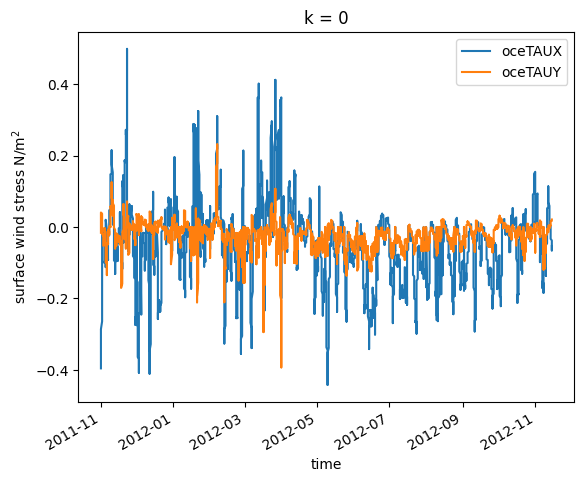

In [19]:
taux_masked.mean(dim='i',skipna=True).mean(dim='j',skipna=True).plot(label='oceTAUX')
tauy_masked.mean(dim='i',skipna=True).mean(dim='j',skipna=True).plot(label= 'oceTAUY' )
plt.legend()
plt.ylabel('surface wind stress N/m$^2$')

Compare to both buoy NDBC (convert from compass to (u,v)_wind -> air sea package ->stress)

In [9]:
path_to_data = '/media/drdarby/Elements/data/Thesis/gliders/buoy'
buoy_files, buoy_filepaths = tools.get_data_paths_from_binary(path_to_data,'',file_end='txt')
data_names = pd.read_csv(buoy_filepaths[0],delimiter='\t').columns
data = pd.read_csv(buoy_filepaths[0],sep='\s+',header=0,na_values=999)

In [62]:
data

,#YY,MM,DD,hh,mm,WDIR,WSPD,GST,WVHT,DPD,APD,MWD,PRES,ATMP,WTMP,DEWP,VIS,TIDE
0,#yr,mo,dy,hr,mn,degT,m/s,m/s,m,sec,sec,degT,hPa,degC,degC,degC,mi,ft
1,2012,01,11,01,50,345,3.4,5.6,99.00,99.00,99.00,NaN,1020.0,11.6,NaN,NaN,99.0,99.00
2,2012,01,11,02,50,358,3.7,4.9,2.19,10.00,8.12,NaN,1020.0,11.5,NaN,NaN,99.0,99.00
3,2012,01,11,03,50,359,3.7,5.2,2.49,11.43,8.10,NaN,1020.3,10.8,NaN,NaN,99.0,99.00
4,2012,01,11,04,50,13,3.7,6.6,2.78,8.33,7.16,NaN,1020.1,10.6,NaN,NaN,99.0,99.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27008,2012,12,31,18,50,329,1.6,3.0,2.01,19.05,9.85,NaN,1026.3,8.1,11.5,NaN,99.0,99.00
27009,2012,12,31,19,50,48,2.8,3.6,1.98,17.39,10.19,NaN,1025.9,8.4,11.5,NaN,99.0,99.00
27010,2012,12,31,20,50,98,3.8,5.0,2.67,17.39,12.12,NaN,1025.3,8.0,11.5,NaN,99.0,99.00
27011,2012,12,31,21,50,98,3.3,4.5,2.37,17.39,11.57,NaN,1025.1,8.4,11.5,NaN,99.0,99.00


In [10]:
data
data_time = []
for i in range(0,len(data['#YY'][1:])):
    year, month, day, hour = data['#YY'][1:][i+1],data['MM'][1:][i+1],data['DD'][1:][i+1],data['hh'][1:][i+1]
    data_time.append(datetime(int(year),int(month),int(day),int(hour)))

ConversionError: Failed to convert value(s) to axis units: '2012-01'

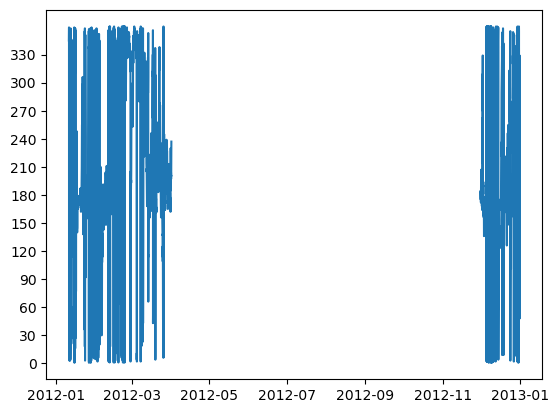

In [70]:
plt.plot(data_time['2012-01','2012-04'],np.array(data['WDIR'][1:]).astype('float'))
plt.yticks(np.arange(0,360,step=30))
plt.xlim('2012-01','2012-04')

In [11]:
def compasstransform(theta):
    '''
    Converts angles between compass direction (clockwise from true North) to direction in polar coordinates (counter-clockwise from x-axis, pointing East).

    Note that regardless of which way the conversion is being done (compass -> polar, or polar -> compass), the output of this function will be the same for a given input.

    INPUT:
    - theta: direction (degrees), numpy array

    OUTPUT:
    - converted direction (degrees), numpy array of same size
        (0 to 360 degrees)
    '''
    theta = np.array(theta)
    theta = theta*np.pi/180. # convert to radians
    x = -np.sin(-theta)
    y = np.cos(-theta)
    theta_out = np.arctan2(y,x)
    theta_out = theta_out*180/np.pi # convert back to degrees
    neg = theta_out < 0
    theta_out[neg] = theta_out[neg]+360
    return theta_out, x, y

In [12]:
wind_speed = np.array(data['WSPD'][1:]).astype('float')


In [13]:
good_theta, x_hat, y_hat = compasstransform(np.array(data['WDIR'][1:]).astype('float'))

In [14]:
wind_dir  = np.array(data['WDIR'][1:]).astype('float')
wind_speed = np.array(data['WSPD'][1:]).astype('float')
wind_x, wind_y = wind_speed*-1*x_hat, wind_speed*-1*y_hat

In [15]:
stress_mag = airsea.windstress.stress(wind_speed, z=4.1)
stress_x, stress_y = stress_mag*-1*x_hat, stress_mag*-1*y_hat

In [16]:
Wind_Stress = pd.DataFrame(data=np.column_stack([stress_x,stress_y,wind_dir,wind_speed]),index = np.array(data_time), columns=['stress_x','stress_y','wind_dir','wind_speed'])

In [141]:
Wind_Stress['2012-01':'2012-04']['wind_dir']

2012-01-11 01:00:00    345.0
2012-01-11 02:00:00    358.0
2012-01-11 03:00:00    359.0
2012-01-11 04:00:00     13.0
2012-01-11 05:00:00    358.0
                       ...  
2012-04-30 20:00:00      NaN
2012-04-30 22:00:00      NaN
2012-04-30 22:00:00      NaN
2012-04-30 23:00:00      NaN
2012-04-30 23:00:00      NaN
Name: wind_dir, Length: 3637, dtype: float64

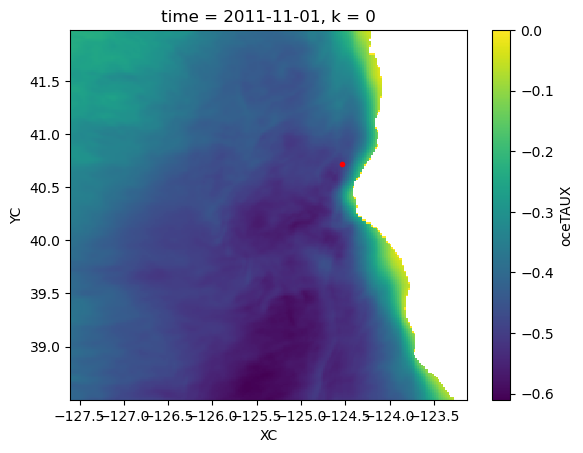

In [119]:
taux_masked.isel(time=0).plot(x='XC',y='YC')
plt.plot(lon,lat,'r.')

In [17]:
lat = 40.716
lon = -124.540

# First, find the index of the grid point nearest a specific lat/lon.   
abslat = np.abs(taux_masked.YC-lat)
abslon = np.abs(taux_masked.XC-lon)
c = np.maximum(abslon, abslat)
ind = np.unravel_index(np.argmin(np.array(c), axis=None),c.shape)
i_buoy = c[ind].i
j_buoy = c[ind].j
# Now I can use that index location to get the values at the x/y diminsion
#point_ds = ds.sel(x=xloc, y=yloc)

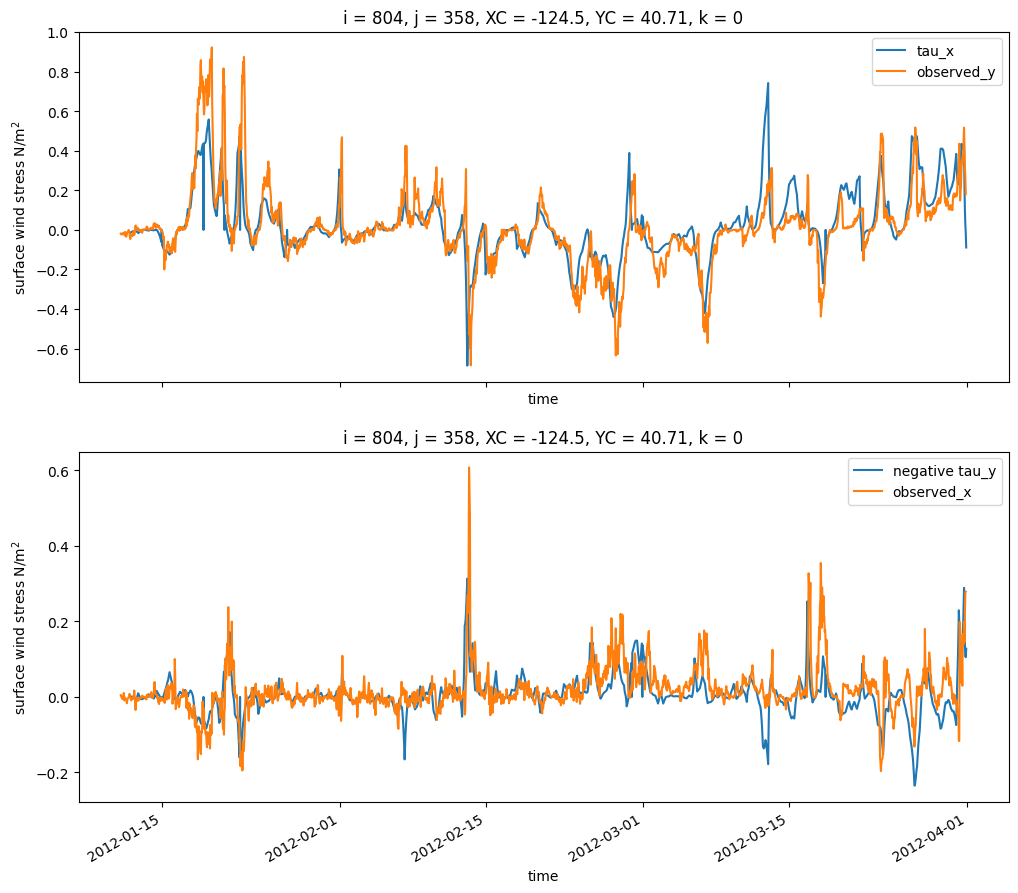

In [35]:
#real labels:

fig,ax = plt.subplots(ncols=1, nrows=2,figsize=(12,10),sharex=True)
taux_masked.sel(i = i_buoy,j=j_buoy,time=slice('2012-01-12','2012-03')).plot(label='tau x',ax=ax[0])
(tauy_masked*-1).sel(i = i_buoy,j=j_buoy,time=slice('2012-01-12','2012-03')).plot(label='negative tau y',ax=ax[1])
ax[0].set_ylabel('surface wind stress N/m$^2$')

ax[0].plot(Wind_Stress['2012-01':'2012-04'].index,Wind_Stress['2012-01':'2012-04']['stress_y'],label='observed y')
ax[1].plot(Wind_Stress['2012-01':'2012-04'].index,Wind_Stress['2012-01':'2012-04']['stress_x'],label='observed x')
ax[1].set_ylabel('surface wind stress N/m$^2$')
ax[0].legend()
ax[1].legend()
#ax[2].plot(Wind_Stress['2012-01':'2012-04'].index,Wind_Stress['2012-01':'2012-04']['wind_dir'])
#ax[2].set_ylabel('wind direction (DegT)')
#ax[3].plot(Wind_Stress['2012-01':'2012-04'].index,Wind_Stress['2012-01':'2012-04']['wind_speed'])
#ax[3].set_ylabel('wind speed (m/s)')

Text(0.5, 1.0, '')

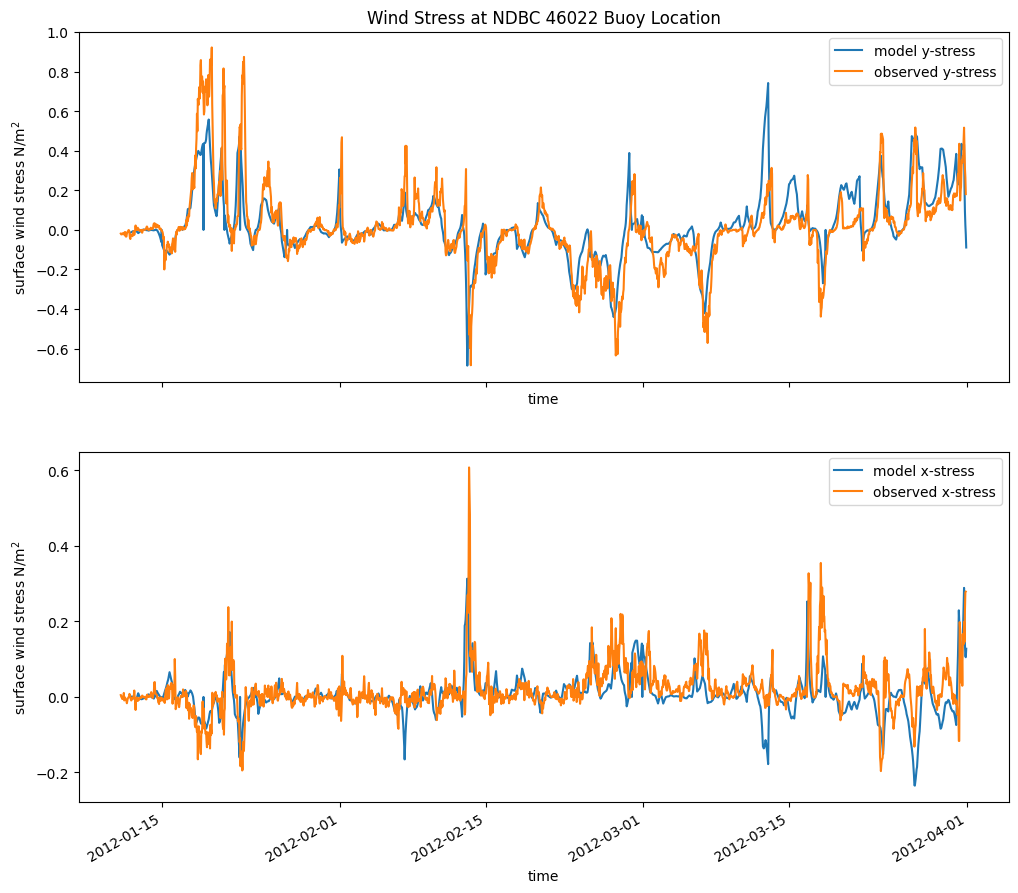

In [38]:
fig,ax = plt.subplots(ncols=1, nrows=2,figsize=(12,10),sharex=True)
taux_masked.sel(i = i_buoy,j=j_buoy,time=slice('2012-01-12','2012-03')).plot(label='model y-stress',ax=ax[0])
(tauy_masked*-1).sel(i = i_buoy,j=j_buoy,time=slice('2012-01-12','2012-03')).plot(label='model x-stress',ax=ax[1])
ax[0].set_ylabel('surface wind stress N/m$^2$')

ax[0].plot(Wind_Stress['2012-01':'2012-04'].index,Wind_Stress['2012-01':'2012-04']['stress_y'],label='observed y-stress')
ax[1].plot(Wind_Stress['2012-01':'2012-04'].index,Wind_Stress['2012-01':'2012-04']['stress_x'],label='observed x-stress')
ax[1].set_ylabel('surface wind stress N/m$^2$')
ax[0].legend()
ax[1].legend()
ax[0].set_title('Wind Stress at NDBC 46022 Buoy Location')
ax[1].set_title('')

(array([15354., 15371., 15385., 15400., 15414., 15431.]),
 [Text(15354.0, 0, '2012-01-15'),
  Text(15371.0, 0, '2012-02-01'),
  Text(15385.0, 0, '2012-02-15'),
  Text(15400.0, 0, '2012-03-01'),
  Text(15414.0, 0, '2012-03-15'),
  Text(15431.0, 0, '2012-04-01')])

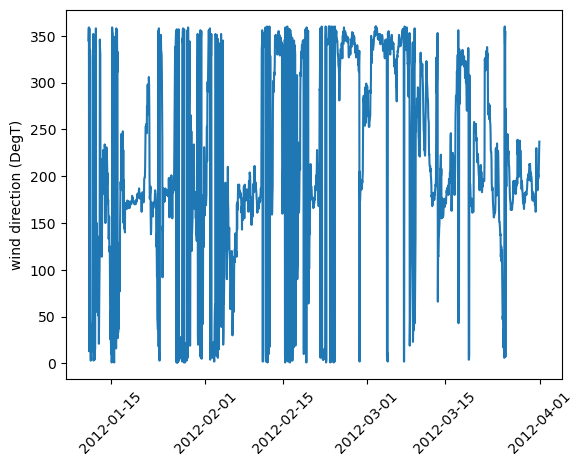

In [143]:
ax[1].plot(Wind_Stress['2012-01':'2012-04'].index,Wind_Stress['2012-01':'2012-04']['wind_dir'])
ax[1].set_ylabel('wind direction (DegT)')
plt.xticks(rotation=45)

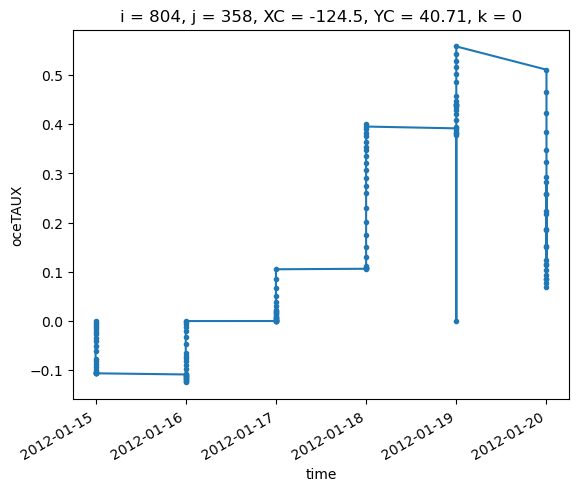

In [169]:
taux_masked.sel(i = i_buoy,j=j_buoy,time=slice('2012-01-15','2012-01-20')).plot(label='tau_x',marker='.')

In [183]:
tauxy.isel(time=slice(30*24,4*30*24))

IOStream.flush timed out


<xarray.Dataset>
Dimensions:  (time: 2160, i: 1486, j: 672, k: 1)
Coordinates:
  * time     (time) datetime64[ns] 2011-12-01 ... 2012-02-28T23:00:00
  * i        (i) int64 0 1 2 3 4 5 6 7 ... 1479 1480 1481 1482 1483 1484 1485
  * j        (j) int64 0 1 2 3 4 5 6 7 8 ... 663 664 665 666 667 668 669 670 671
    XC       (i, j) float32 ...
    YC       (i, j) float32 ...
  * k        (k) int64 0
Data variables: (12/14)
    oceTAUX  (time, i, j) float32 dask.array<chunksize=(1, 1486, 672), meta=np.ndarray>
    oceTAUY  (time, i, j) float32 dask.array<chunksize=(1, 1486, 672), meta=np.ndarray>
    DXC      (i, j) float32 ...
    DXG      (i, j) float32 ...
    DXV      (i, j) float32 ...
    DYC      (i, j) float32 ...
    ...       ...
    Depth    (i, j) float32 ...
    RAC      (i, j) float32 ...
    RAZ      (i, j) float32 ...
    XG       (i, j) float32 ...
    YG       (i, j) float32 ...
    hFacC    (i, j, k) float32 ...

In [ ]:
###In Numpy

bin_path = '/mnt/thesis_model_data/Data/LLC4320/norcal_surf'
taux_files, taux_filepaths = tools.get_data_paths_from_binary(path_tohd,variables[-2],file_end='nc')
tauy_files, tauy_filepaths = tools.get_data_paths_from_binary(path_tohd,variables[-1],file_end='nc')



In [ ]:
y_stress_bin_files, y_stress_bin_filepath = tools.get_data_paths_from_binary(bin_path,variables[-1])
x_stress_bin_files, x_stress_bin_filepath = tools.get_data_paths_from_binary(bin_path,variables[-2],file_end='1_Neg')
location = (0,10)

for i in range(0,len(x_stress_bin_files)):
    time_itter=data_files[i][location[0]:location[1]]
    time = [tools.convert_itter_to_datetime(time_itter,datetime(2011,9,10),25)]
    if time[0]


In [186]:
bin_path = '/mnt/thesis_model_data/Data/LLC4320/norcal_surf/'

i=0
y_stress_bin_files, y_stress_bin_filepath = tools.get_data_paths_from_binary(bin_path,variables[-1])
x_stress_bin_files, x_stress_bin_filepath = tools.get_data_paths_from_binary(bin_path,variables[-2],file_end='1_Neg')


NameError: name 'data_files' is not defined

In [264]:
import numpy as np
from datetime import datetime
from datetime import timedelta
import os
import sys
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

def get_data_paths_from_binary(path_to_data,variable,delim='.',file_end='1'):
    '''This function returns a list of file names and paths with filenames to the files that you want given the path to the data and the varible directory. Returns sorted
        e.g.
        path_to_data = ./home/user/data/ 
        varible = var1
        get_data_path_from_binary(path_to_data,variable,delim='.',file_end='1')
        where delim,file_end selects for what file ending will be chosen
        returns
        ['d.a.t.a1.1','d.a.t.a2.1','d.a.t.a3.1'],['./home/user/data/var1/d.a.t.a1.1',''./home/user/data/var1/d.a.t.a2.1'',''./home/user/data/var1/d.a.t.a3.1'']
        '''
    all_paths = []
    filename_ = []
    for filename in os.listdir(path_to_data + variable):
        f = os.path.join(path_to_data,variable, filename)
    # checking if it is a file
        if filename.split(delim)[-1]==file_end:
            all_paths.append(filename)
            filename_.append(f)
    return sorted(all_paths), sorted(filename_)


def convert_itter_to_datetime(number,datetime_start,timestep,shift_itter=0):
    '''converts an itteration number to a datetime'''
    itter_dt = datetime.fromtimestamp(datetime_start.timestamp()+(int(number)+int(shift_itter))*timestep)
    return itter_dt
location = (0,10)

bin_path = '/mnt/thesis_model_data/Data/LLC4320/norcal_surf/'
variables = ['Eta','Theta','Salt','U','V','W','oceTAUX','oceTAUY']

y_stress_bin_files, y_stress_bin_filepath = get_data_paths_from_binary(bin_path,variables[-1])
x_stress_bin_files, x_stress_bin_filepath = get_data_paths_from_binary(bin_path,variables[-2],file_end='1_Neg')

i_ind_buoy = 804
j_ind_buoy = 358
j0 = np.arange(672)
i0 = np.arange(1486)
x_stress_values = []
y_stress_values = []
time_span = []
date_range = [datetime(2012, 1, 15, 0),datetime(2012, 4, 1, 0)]
for i in tqdm(range(0,len(x_stress_bin_files))):
    time_itter=x_stress_bin_files[i][location[0]:location[1]]
    time = [convert_itter_to_datetime(time_itter,datetime(2011,9,10),25)]
    shape = (len(i0),len(j0))
    if (time[0]>date_range[0])and(time[0]<date_range[1]):
        file_x = np.fromfile(x_stress_bin_filepath[i],'>f4')
        file_x = np.reshape(file_x, shape)
        file_y = np.fromfile(y_stress_bin_filepath[i],'>f4')
        file_y = np.reshape(file_y, shape)
        x_stress_values.append(file_x[i_ind_buoy,j_ind_buoy])
        y_stress_values.append(file_y[i_ind_buoy,j_ind_buoy])
        time_span.append(time[0])

fig,ax = plt.subplots(ncols=1, nrows=2,figsize=(12,10),sharex=True)
ax[0].plot(time_span,x_stress_values,label='tau_x')
ax[1].plot(time_span,y_stress_values,label='tau_y')
ax[0].set_ylabel('surface wind stress N/m$^2$')
ax[1].set_ylabel('surface wind stress N/m$^2$')

ax[0].legend()
ax[1].legend()

  0%|          | 0/9121 [00:00<?, ?it/s]

KeyboardInterrupt: 

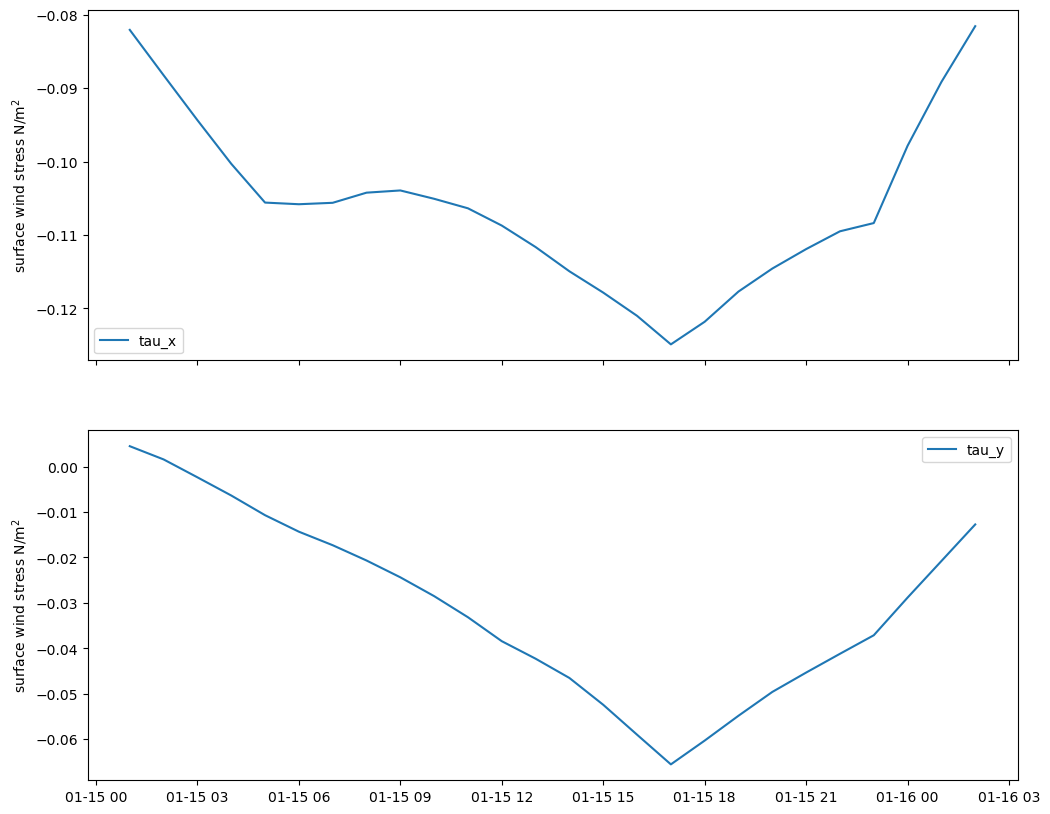

In [266]:
fig,ax = plt.subplots(ncols=1, nrows=2,figsize=(12,10),sharex=True)
ax[0].plot(time_span,x_stress_values,label='tau_x')
ax[1].plot(time_span,y_stress_values,label='tau_y')
ax[0].set_ylabel('surface wind stress N/m$^2$')
ax[1].set_ylabel('surface wind stress N/m$^2$')

ax[0].legend()
ax[1].legend()

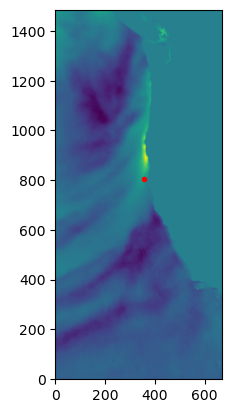

In [257]:
i=25

file_x = np.fromfile(x_stress_bin_filepath[i],'>f4')
file_x = np.reshape(file, shape)
file_y = np.fromfile(y_stress_bin_filepath[i],'>f4')
file_y = np.reshape(file, shape)
x_stress_values.append(file_x[i_ind_buoy,j_ind_buoy])
y_stress_values.append(file_y[i_ind_buoy,j_ind_buoy])
plt.imshow(file_x)
plt.plot(j_buoy,i_buoy,'r.')
plt.gca().invert_yaxis()

In [263]:
(file_x==file_y).sum()/(file_x==file_x).sum()

1.0

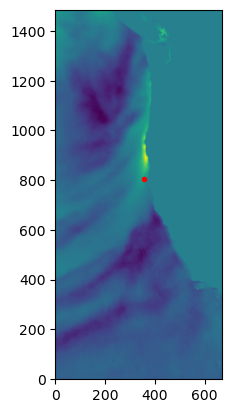

In [256]:
plt.imshow(file_x)
plt.plot(j_buoy,i_buoy,'r.')
plt.gca().invert_yaxis()

In [246]:
x_stress_bin_filepath[i]
x_stress_bin_filepath[i+1]

'/mnt/thesis_model_data/Data/LLC4320/norcal_surf/oceTAUX/0000467856_oceTAUX_12769.9439.1_672.1486.1_Neg'

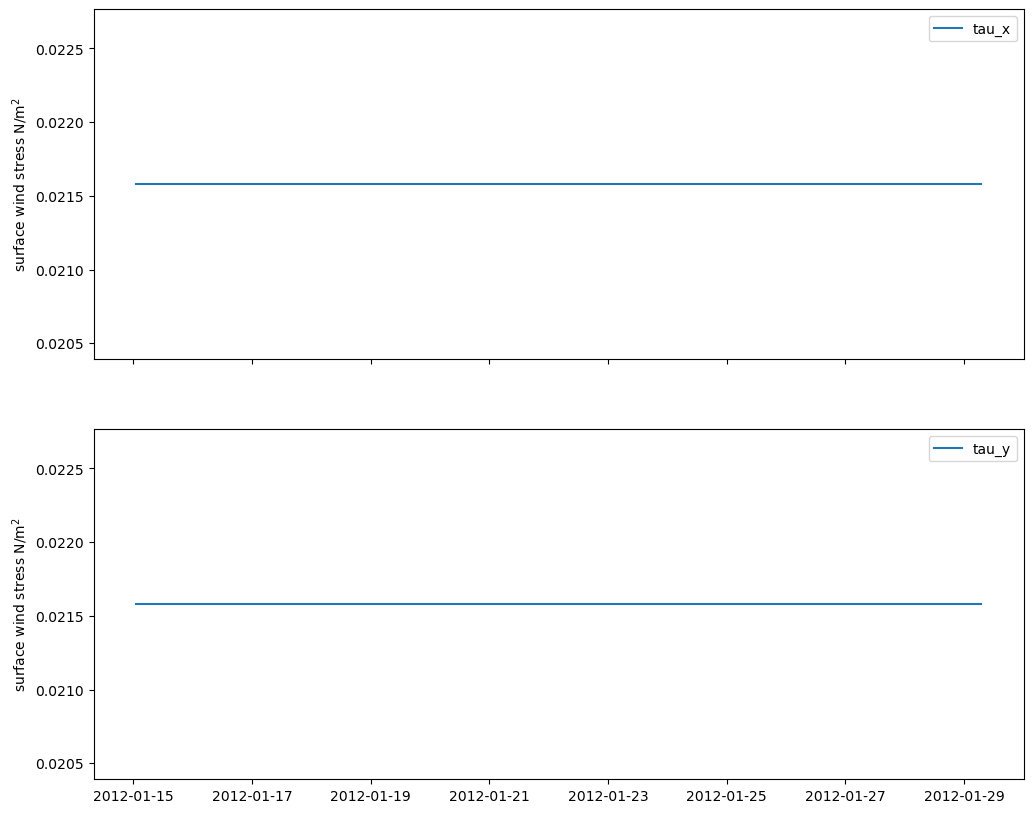

In [224]:
fig,ax = plt.subplots(ncols=1, nrows=2,figsize=(12,10),sharex=True)
ax[0].plot(time_span,x_stress_values,label='tau_x')
ax[1].plot(time_span,y_stress_values,label='tau_y')
ax[0].set_ylabel('surface wind stress N/m$^2$')
ax[1].set_ylabel('surface wind stress N/m$^2$')

ax[0].legend()
ax[1].legend()

In [208]:

file[0,i_buoy,j_buoy]

0.021578113

In [220]:
i_ind_buoy = 804
j_ind_buoy = 358
j_buoy

<xarray.DataArray 'j' ()>
array(358)
Coordinates:
    i        int64 804
    j        int64 358
    XC       float32 -124.5
    YC       float32 40.71
    k        int64 0

In [217]:
np.array(taux_masked.sel(i = i_buoy,j=j_buoy,time=slice('2012-01-29 23','2012-02'))[0])

array(0.02157811, dtype=float32)